In [128]:
import pandas as pd
import seaborn as sns
import thinkstats2
import thinkplot
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# Scipy Distributions in More Detail

We can look at scipy and creating distributions in a little more detail here. 

## Normal Distribution



In [129]:
dfSpotify = pd.read_csv("data/spotify-2023.csv", encoding="ISO-8859-1")
#sns.pairplot(dfSpotify)
spotDance = dfSpotify["danceability_%"]


#### Is it Normal? 

We can check normality in a few ways:
<ul>
<li> Visually via a histogram or CDF plot </li>
<li> Visually, using a normality plot </li>
<li> Statistically, using a normality test </li>
</ul>

<Axes: xlabel='danceability_%', ylabel='Density'>

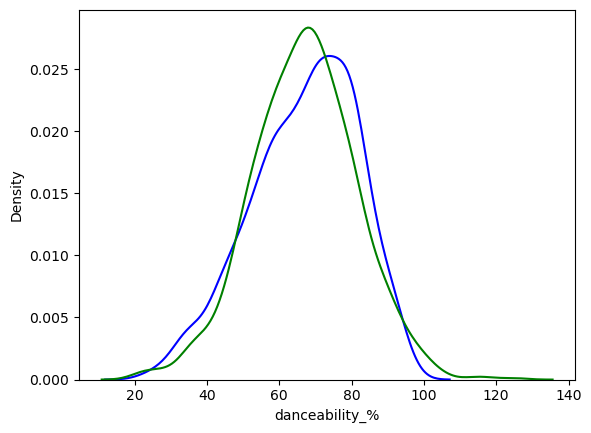

In [130]:
sns.kdeplot(spotDance, color="blue", label="Original Data")
sns.kdeplot(np.random.normal(loc=spotDance.mean(), scale=spotDance.std(), size=len(spotDance)), color="green", label="Normal Model")

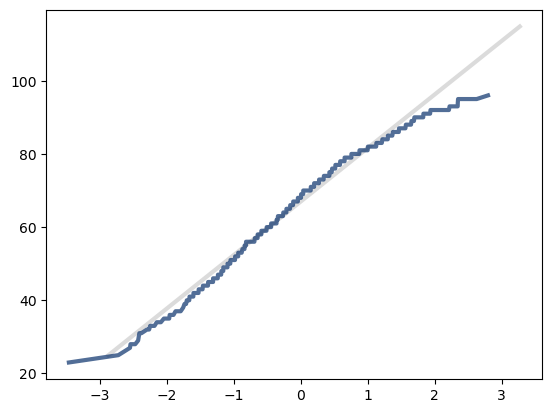

In [131]:
thinkstats2.NormalProbabilityPlot(spotDance, label="Original Data")

##### Shapiro-Wilk Test for Normality

This test is a common statistical test for normality. The null hypothesis is that the data is normally distributed. If the p-value is less than 0.05, we reject the null hypothesis and conclude that the data is not normally distributed. If the p-value is greater than 0.05, we fail to reject the null hypothesis and conclude that the data is normally distributed.

This test isn't perfect, in particular if the dataset is quite large it may reject the null hypothesis even if the data is approximately normal; if the dataset is very small, it may fail to reject the null hypothesis even if the data is not normal. 

<b>Note:</b> this is a tool, but don't rely on it alone. 

In [132]:
# Analytical Test
isNormal = scipy.stats.shapiro(spotDance)
print("Shapiro-Wilk Test for Normality: ", isNormal)

if isNormal.pvalue > 0.05:
    print("The data is normally distributed.")
else:
    print("The data is not normally distributed.")

Shapiro-Wilk Test for Normality:  ShapiroResult(statistic=0.9797062277793884, pvalue=2.960318934430717e-10)
The data is not normally distributed.


#### Create Models

Looks normal enough, let's try. 

##### Generate Statistics

The only statistics needed to create a normal distribution are the mean and standard deviation, we can capture these and create a distribution directly from them. 

In [133]:
spotMean = spotDance.mean()
spotStd = spotDance.std()
spotN = len(spotDance)
print(f"Mean: {spotMean}, Std: {spotStd}")

spotNormal = scipy.stats.norm(loc=spotMean, scale=spotStd)
print(type(spotNormal))
print("Model Stats:")
print(f"Mean: {spotNormal.mean()}, Std: {spotNormal.std()}")
spotNormalSample = spotNormal.rvs(size=spotN)

Mean: 66.96956977964324, Std: 14.6306098744348
<class 'scipy.stats._distn_infrastructure.rv_continuous_frozen'>
Model Stats:
Mean: 66.96956977964324, Std: 14.6306098744348


##### Fit Automatically

Now, we can try using the fit function to automatically fit a normal distribution to the data. This function will return the parameters of the fitted distribution.

##### Frozen Distributions

In scipy parlance, a "frozen" distribution is a distribution that has been created with specific parameters (like mean and standard deviation for a normal distribution) and can be used to generate random samples or compute probabilities. This is in contrast to a "generic" distribution, which can do things like generate samples, but are not 'permanent'. 

In [134]:
spotNormFit = scipy.stats.norm.fit(spotDance)
print(f"Fit Mean: {spotNormFit[0]}, Fit Std: {spotNormFit[1]}")

spotStats = spotNormal.stats(moments="mvsk")
print("\nModel from Fit:")
print("\tMean: ", spotStats[0])
print("\tVariance: ", spotStats[1])
print("\tSkewness: ", spotStats[2])
print("\tKurtosis: ", spotStats[3])
spotFrozen = scipy.stats.norm(loc=spotNormFit[0], scale=spotNormFit[1])
print(f"Frozen Mean: {spotFrozen.mean()}, Frozen Std: {spotFrozen.std()}")
spotFrozenSample = spotFrozen.rvs(size=spotN)

Fit Mean: 66.96956977964324, Fit Std: 14.622931778983714

Model from Fit:
	Mean:  66.96956977964324
	Variance:  214.05474529790908
	Skewness:  0.0
	Kurtosis:  0.0
Frozen Mean: 66.96956977964324, Frozen Std: 14.622931778983714


##### Example - Non-Frozen Distribution

We can use a non-frozen distribution to generate random samples directly, there's no real difference between this and a frozen distribution, but the frozen distribution is more convenient if you want to use the same parameters multiple times.

<Axes: ylabel='Density'>

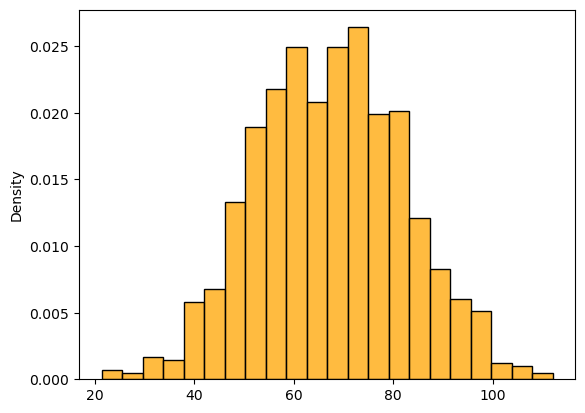

In [135]:
# Example random values, non-frozen
random_normal = scipy.stats.norm.rvs(loc=spotMean, scale=spotStd, size=1000)
sns.histplot(random_normal, color="orange", stat="density", label="Random Normal Sample")

#### Results and Plots

We can now check to see how well our model fits the data. 

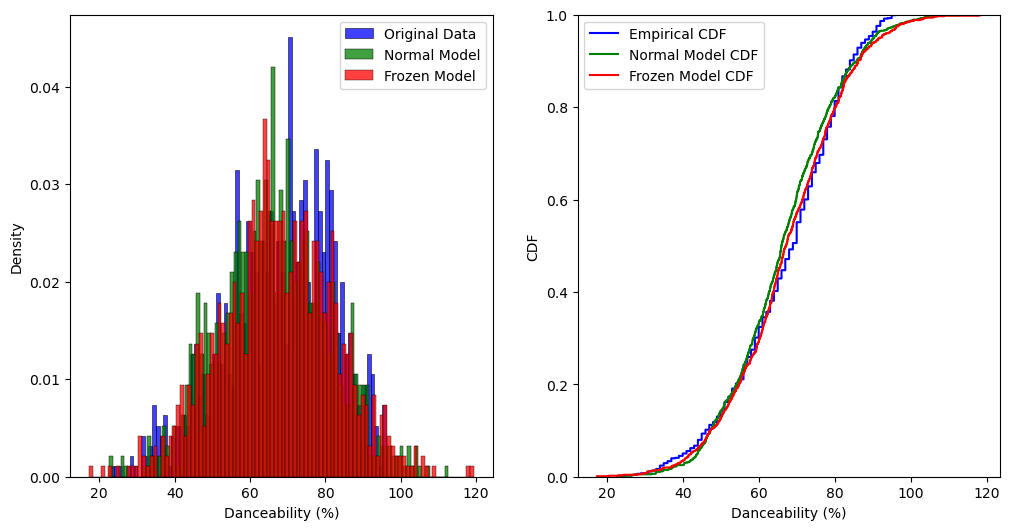

<Figure size 800x600 with 0 Axes>

In [136]:
thinkplot.clf()
thinkplot.PrePlot(2, rows=1, cols=2)
thinkplot.subplot(1)
sns.histplot(data=spotDance, color="blue", stat="density", binwidth=1, label="Original Data")
sns.histplot(spotNormalSample, color="green", stat="density", binwidth=1, label="Normal Model")
sns.histplot(spotFrozenSample, color="red", stat="density", binwidth=1, label="Frozen Model")
thinkplot.config(xlabel="Danceability (%)", ylabel="Density", legend=True)
thinkplot.subplot(2)
sns.ecdfplot(data=spotDance, color="blue", label="Empirical CDF")
sns.ecdfplot(spotNormalSample, color="green", label="Normal Model CDF")
sns.ecdfplot(spotFrozenSample, color="red", label="Frozen Model CDF")
thinkplot.config(xlabel="Danceability (%)", ylabel="CDF", legend=True)
thinkplot.show()

### Cumulative Calculations

We can use the distributions to calculate a bunch of things, first, let's look at the cumulative distribution function (CDF) and the percent point function (PPF).

#### Very Danceable Songs

I'm opening a nightclub and I want two things:
<ul>
<li> Very danceable songs, to keep it poppin. </li>
<li> Low-medium danceable songs, to get people buying drinks. </li>
</ul>

So, I want to know about songs that are 80%+, as well as songs that are 30%-50%, so I can build my sick playlist. 

In [137]:
# 80%+ Danceable
veryDanceableCutoff = 80
percentVeryDanceable = 1 - spotFrozen.cdf(veryDanceableCutoff)
print(f"Percent of songs with danceability > {veryDanceableCutoff}%: {percentVeryDanceable:.2%}")

Percent of songs with danceability > 80%: 18.64%


In [138]:
# Moderate Danceability
moderateCutoffs = (30, 50)
percentModerateDanceable = spotFrozen.cdf(moderateCutoffs[1]) - spotFrozen.cdf(moderateCutoffs[0])
print(f"Percent of songs with danceability between {moderateCutoffs[0]}% and {moderateCutoffs[1]}%: {percentModerateDanceable:.2%}")

Percent of songs with danceability between 30% and 50%: 11.72%


Text(0, 0.5, 'Density')

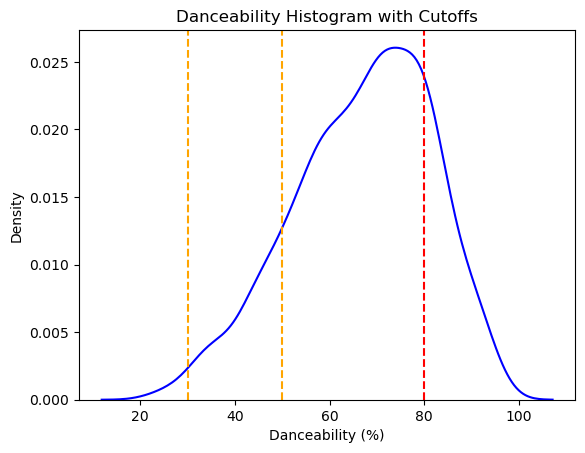

In [139]:
sns.kdeplot(spotDance, color="blue", label="Original Data")
plt.axvline(x=veryDanceableCutoff, color="red", linestyle="--", label="80% Cutoff")
plt.axvline(x=moderateCutoffs[0], color="orange", linestyle="--", label="30% Cutoff")
plt.axvline(x=moderateCutoffs[1], color="orange", linestyle="--", label="50% Cutoff")
plt.title("Danceability Histogram with Cutoffs")
plt.xlabel("Danceability (%)")
plt.ylabel("Density")

## Exponential Distribution

This dataset contains data on computing power, year over year. The value we care about is gigaflops, or billions of floating point operations per second. They say computers have gotten exponentially faster, have they? 

In [140]:
expoData = pd.read_csv("data/supercomputerpowerflops new.csv")
gflops = expoData["GFLOPS"]

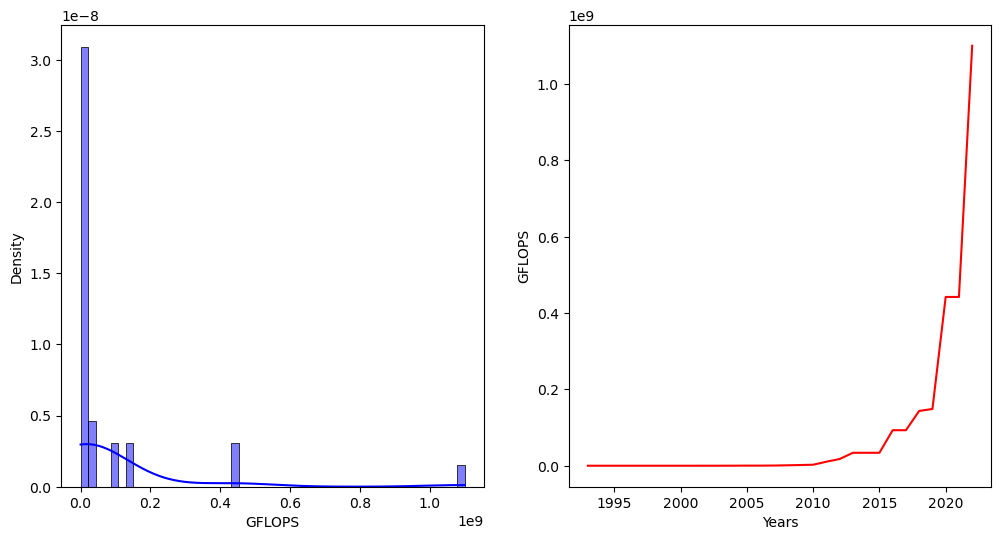

In [141]:
thinkplot.PrePlot(2, rows=1, cols=2)
thinkplot.subplot(1)
sns.histplot(data=expoData, x="GFLOPS", color="blue", stat="density", kde=True)
thinkplot.config(xlabel="GFLOPS", ylabel="Density", legend=False)
thinkplot.subplot(2)
sns.lineplot(data=expoData, x="Years", y="GFLOPS", color="red")
thinkplot.config(xlabel="Years", ylabel="GFLOPS", legend=False)

#### Exponential Check

We can check to see if the data is exponentially distributed by looking at the cdf as well as the log plot. If our data is exponential, a line plot should be close to a straight line on the log plot.

[None]

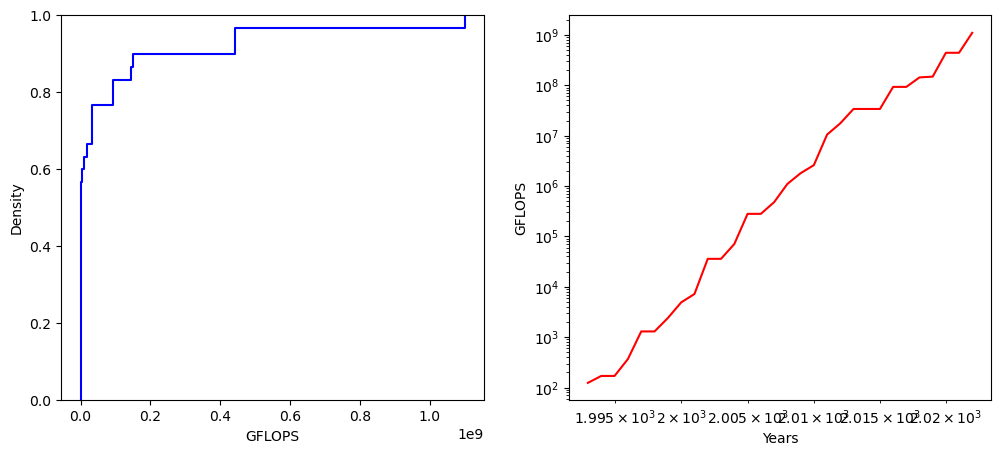

In [169]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.ecdfplot(data=expoData, x="GFLOPS", color="blue", ax=ax[0])
ax[0].set_xlabel("GFLOPS")
ax[0].set_ylabel("Density")
ax[1].set(xscale="log", yscale="log")
sns.lineplot(data=expoData, x="Years", y="GFLOPS", color="red", ax=ax[1])
ax[1].set_xlabel("Years")
ax[1].set_ylabel("GFLOPS")
ax[1].set(yscale="log")

Looks pretty exponential. Let's try to fit an exponential distribution to the data.

### Exponential Statistics

To make an exponential distribution, we need to find the scale and location parameters.

#### Lambda and Scale

Exponential distributions are often parameterized by a rate parameter, lambda (λ), which is the expected number of events per unit time. The scale parameter is the inverse of lambda, so scale = 1/λ. We can calculate both of these values from the mean as well, the mean is equal to 1/λ, so λ = 1/mean, and scale = mean. So:
<ul>
<li> Lambda = 1/mean (Events per unit time) </li>
<li> Scale = mean (Time between events) </li>
</ul>

#### Location

The location, or threshold value, is a parameter that shifts the distribution along the x-axis, specifically it is the minimum value of the distribution. In this case, we can use the minimum value of the data as the location parameter.

#### Calculate by Extracting Stats

In [143]:
gflopsMean = gflops.mean()
gflopsLambda = 1 / gflopsMean
gflopsScale = 1 / gflopsLambda
print("Calculated Stats:")
print("\tMean:", gflopsMean)
print("\tLambda:", gflopsLambda)
print("\tScale:", gflopsScale)
print("\tMin:", gflops.min())

gflopsExponent = scipy.stats.expon(scale=gflopsScale, loc=gflops.min())
gfExpStats = gflopsExponent.stats(moments='mvsk')
print("\nModel from Scale:")
print("\tMin:", gflopsExponent.ppf(0))
print("\tMean:", gfExpStats[0])
print("\tVariance:", gfExpStats[1])
print("\tSkewness:", gfExpStats[2])
print("\tKurtosis:", gfExpStats[3])

Calculated Stats:
	Mean: 86619994.4
	Lambda: 1.1544678649852232e-08
	Scale: 86619994.4
	Min: 124

Model from Scale:
	Min: 124.0
	Mean: 86620118.4
	Variance: 7503023429856032.0
	Skewness: 2.0
	Kurtosis: 6.0


#### Use Fit Method

We can automatically fit a distribution and compare. 

##### Fixing a Parameter

When creating scipy distributions, we can fix parameters to specific values. This is useful when we want to fit a distribution to data, but we want to constrain one or more of the parameters to a specific value. When the fit function is fitting, it needs to find optimal values for *all* of the parameters. In some scenarios, such as when we have prior knowledge about the data, or if we are testing a hypothesis such as "the data is normally distributed with a mean of 0", we may want to fix one or more of the parameters to specific values. The fixed variables are not optimized during the fitting process, and they are instead set to the specified values. 

This can feel odd at times, but it stems from the fact that we are dealing with approximations all over the place. The sample(s) are an approximation of the population, and the fitted distribution is an approximation of the sample(s). If we have any aspects that we *know* for a fact, we can fix those and effectively remove them from the approximation. 

To fix a parameter, we can use the `floc` and `fscale` arguments in the `fit` method. The `floc` argument allows us to fix the location parameter to a specific value, and the `fscale` argument allows us to fix the scale parameter to a specific value.

In [144]:
gflopsFit = scipy.stats.expon.fit(gflops, floc=gflops.min())
print("Fitted Parameters:", gflopsFit)
gflopsFrozen = scipy.stats.expon(*gflopsFit)
gfFitStats = gflopsFrozen.stats(moments='mvsk')
print("\nModel from Fit:")
print(type(gflopsFrozen))
print("\tMin:", gflopsFrozen.ppf(0))
print("\tMean:", gfFitStats[0])
print("\tVariance:", gfFitStats[1])
print("\tSkewness:", gfFitStats[2])
print("\tKurtosis:", gfFitStats[3])

Fitted Parameters: (124.0, 86619870.4)

Model from Fit:
<class 'scipy.stats._distn_infrastructure.rv_continuous_frozen'>
	Min: 124.0
	Mean: 86619994.4
	Variance: 7503001948112797.0
	Skewness: 2.0
	Kurtosis: 6.0


#### Results and Plotting

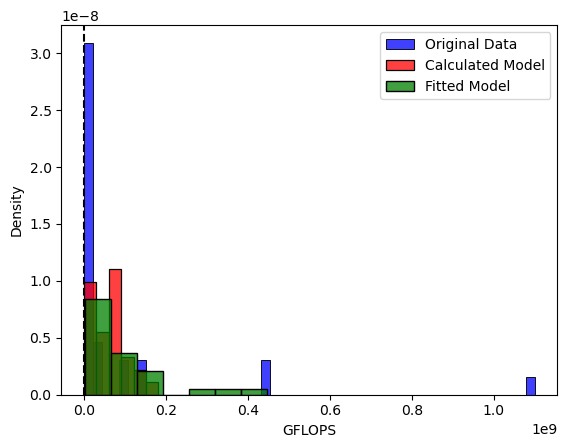

In [145]:
gflopsOrigN = len(gflops)
gflopsSample = gflopsExponent.rvs(size=gflopsOrigN)
gflopsFitSample = gflopsFrozen.rvs(size=gflopsOrigN)

sns.histplot(data=gflops, color="blue", stat="density", label="Original Data")
sns.histplot(gflopsSample, color="red", stat="density", label="Calculated Model")
sns.histplot(gflopsFitSample, color="green", stat="density", label="Fitted Model")
thinkplot.config(xlabel="GFLOPS", ylabel="Density", legend=True)
plt.axvline(0, color="black", linestyle="--", label="Zero GFLOPS")

## Poisson Distribution

Poisson distributions are discrete distributions that are often used to model the number of events that occur in a fixed interval of time or space. This tends to be useful for modeling things like "how many customers arrived", "number of goals in a game", or similar things.

We'll look at the number of *support interactions*, or the number of times a customer is in contact with customer support. This is a discrete variable, we can only have whole numbers of interactions, so a Poisson distribution is a good candidate for modeling this data.

In [146]:
df_custys = pd.read_csv("data/retail_customer_segmentation.csv")
df_custys.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


Text(0.5, 1.0, 'Support Interactions ECDF')

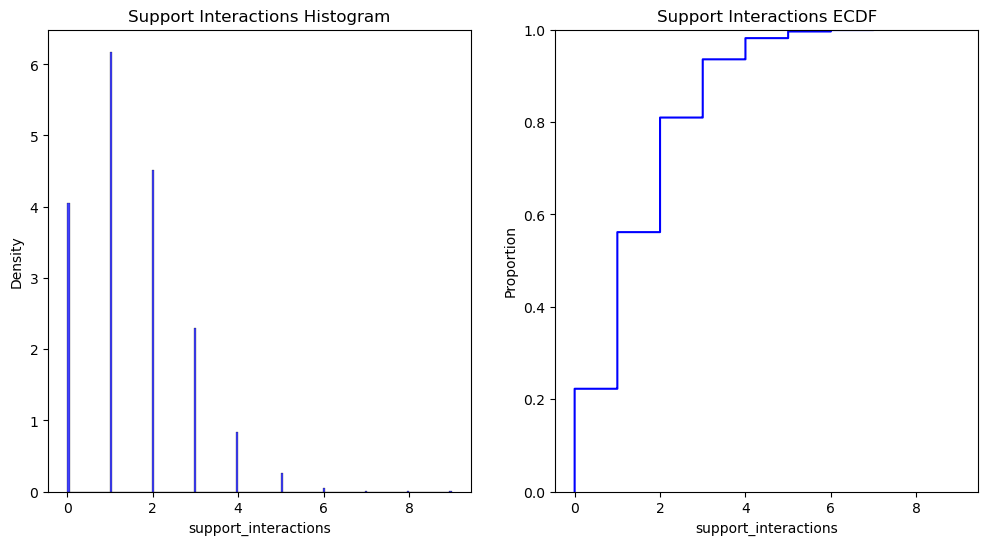

In [147]:
custyInteractions = df_custys["support_interactions"]
thinkplot.PrePlot(2, rows=1, cols=2)
thinkplot.subplot(1)
sns.histplot(data=df_custys, x="support_interactions", color="blue", stat="density")
plt.title("Support Interactions Histogram")
thinkplot.subplot(2)
sns.ecdfplot(data=df_custys, x="support_interactions", color="blue", label="Empirical CDF")
plt.title("Support Interactions ECDF")

#### Get the Stats and Model

We can create a Poisson distribution from the mean of the data, or the expected value of the number of interactions. 

In [148]:
custyMean = custyInteractions.mean()
custyN = len(custyInteractions)
print("Mean:", custyMean)
print("Count:", custyN)

custyPoisson = scipy.stats.poisson(mu=custyMean)
custyPoissonStats = custyPoisson.stats(moments='mvsk')
print("\nModel Stats:")
print("\tMean:", custyPoissonStats[0])
print("\tVariance:", custyPoissonStats[1])
print("\tSkewness:", custyPoissonStats[2])
print("\tKurtosis:", custyPoissonStats[3])

custyPoissonSample = custyPoisson.rvs(size=custyN)

Mean: 1.4946055152878448
Count: 50000

Model Stats:
	Mean: 1.4946055152878448
	Variance: 1.4946055152878448
	Skewness: 0.8179687456794602
	Kurtosis: 0.6690728689084295


#### Results and Plotting

The plot here isn't the most clear, but the model is a pretty good fit to the data, our sample generated from the model looks very similar to the real data. 

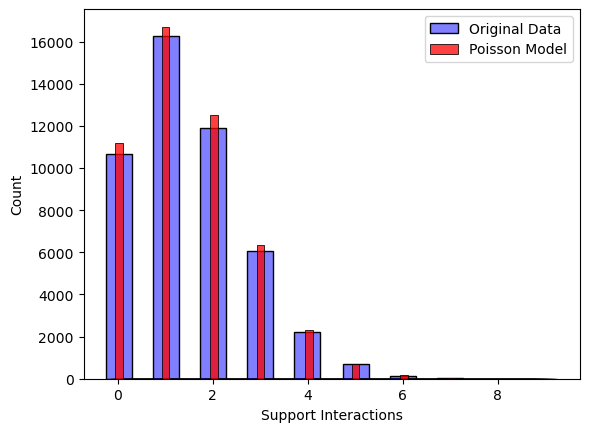

In [149]:
sns.histplot(custyInteractions, color="blue", label="Original Data", shrink=10, alpha=0.5)
sns.histplot(custyPoissonSample, color="red", label="Poisson Model", shrink=3)
thinkplot.config(xlabel="Support Interactions", legend=True)

### Calculations - PMF (or PDF)

The pmf allows us to calculate the probability of a specific number of events occurring, or basically look up a value from the pmf of the distribution. Here, we'll collect the probabilites of getting values from 0 to 7 interactions. 

<b>Note:</b> for continuous distributions, the pdf() is the equivalent. 

In [150]:
limit = 8
probs = []
for i in range(limit):
    prob = custyPoisson.pmf(i)
    print(f"Probability of {i} interactions: {prob:.4f}")
    probs.append(prob)
print("\nSum of probabilities for 0 to", limit-1, "interactions:", sum(probs))

Probability of 0 interactions: 0.2243
Probability of 1 interactions: 0.3353
Probability of 2 interactions: 0.2506
Probability of 3 interactions: 0.1248
Probability of 4 interactions: 0.0466
Probability of 5 interactions: 0.0139
Probability of 6 interactions: 0.0035
Probability of 7 interactions: 0.0007

Sum of probabilities for 0 to 7 interactions: 0.9998344746486303


## Log-Normal

This is data on the number of playlists that a song is in on Spotify. It is very skewed, and we can try to model it with a log-normal distribution. Log-normal distributions are normal-ish, but are right skewed and tend to have long tails. This is a common distribution for things like income, or other things that are bounded by 0 and have a long tail.

The definition of a log-normal distribution is that if a random variable X is log-normally distributed, then Y = ln(X) is normally distributed. This means that the logarithm of the variable follows a normal distribution. Scipy makes this fact a little annoying, because the log-normal distribution is parameterized by the mean and standard deviation of the underlying normal distribution, not the mean and standard deviation of the log-normal distribution itself.

Text(0.5, 1.0, 'Log-Transformed Playlists Histogram')

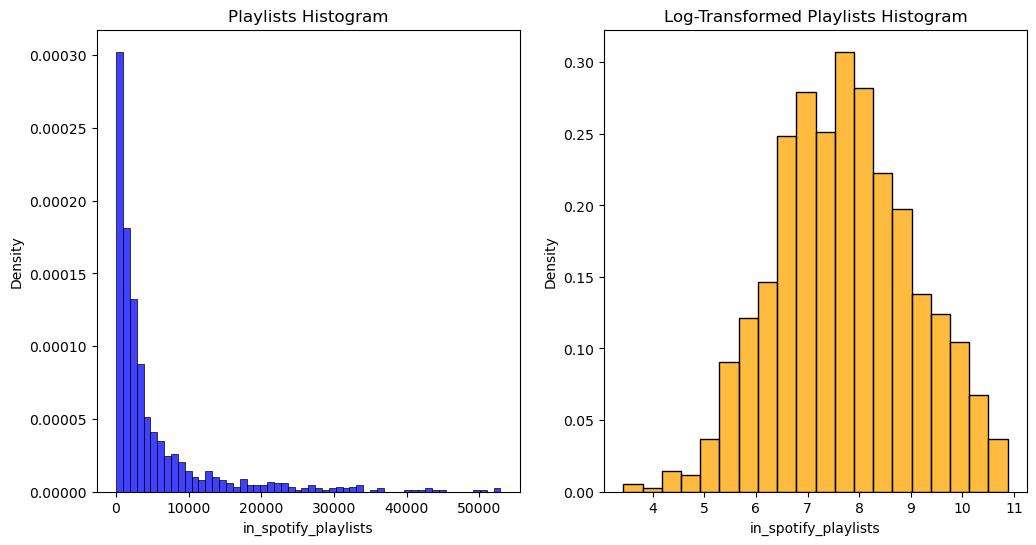

In [151]:
thinkplot.preplot(2, 1, 2)
thinkplot.SubPlot(1)
playlists = dfSpotify["in_spotify_playlists"]
#playlists = playlists/max(playlists)
sns.histplot(data=playlists, color="blue", stat="density")
plt.title("Playlists Histogram")
thinkplot.SubPlot(2)
sns.histplot(np.log(playlists), color="orange", stat="density")
plt.title("Log-Transformed Playlists Histogram")

##### Check Normality Plots

We can check the normality of the data by looking at it and the log on a normal probability plot. 

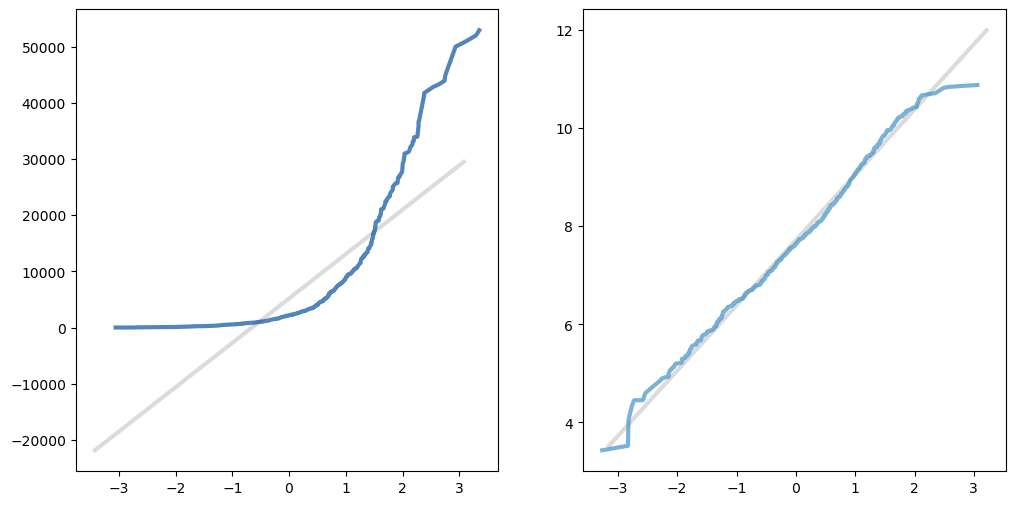

In [152]:
thinkplot.preplot(2, 1, 2)
thinkplot.SubPlot(1)
thinkstats2.NormalProbabilityPlot(playlists, label="Original Data")
thinkplot.SubPlot(2)
thinkstats2.NormalProbabilityPlot(np.log(playlists), label="Log of Data")

#### Get the statistics.

The lognormal distribution is a little weird to deal with if we are trying to fit it to data. The lognormal distribution is defined in terms of the mean and standard deviation of the underlying normal distribution, which is the logarithm of the lognormal variable. This means that when we fit a lognormal distribution to data, we are actually fitting a normal distribution to the logarithm of the data. It also means that the inputs we need to provide are in terms of the underlying normal data, not the lognormal data. I don't really understand the design choice here to organize things like that in scipy, but it is what it is. I think that it would be easier if the lognormal distribution allowed you to create it directly, with statistics calculated directly from the lognormal data, but that is not how it is designed. So:
<ul>
<li> Mean = np.mean(np.log(data)) </li>
    <ul>
    <li> This is the mean of the underlying normal distribution, which is the logarithm of the lognormal variable. </li>
    </ul>
<li> Standard Deviation = np.std(np.log(data)) </li>
    <ul>
    <li> This is the standard deviation of the underlying normal distribution, which is the logarithm of the lognormal variable. </li>
    </ul>
</ul>

In [153]:
# Generate underlying normal data for stats
logPlay = np.log(playlists)
logMean = logPlay.mean()
logStd = logPlay.std()
playOrigN = len(playlists)
print("Log-Normal Stats:")
print("\tMean:", logMean)
print("\tExponential of Mean:", np.exp(logMean))
print("\tStd:", logStd)
print("\tCount:", playOrigN)

Log-Normal Stats:
	Mean: 7.716850332841495
	Exponential of Mean: 2245.8746711786775
	Std: 1.3309151909948231
	Count: 953


##### Create Model from the Statistics

In [154]:
playLogNorm = scipy.stats.lognorm(s=logStd, scale=np.exp(logMean))
playLogNormStats = playLogNorm.stats(moments='mvsk')
print("\nLog-Normal Model Stats:")
print("\tMean:", playLogNormStats[0])
print("\tExponent of Mean:", np.exp(playLogNormStats[0]))
print("\tVariance:", playLogNormStats[1])
print("\tStd Dev:", np.sqrt(playLogNormStats[1]))
print("\tSkewness:", playLogNormStats[2])
print("\tKurtosis:", playLogNormStats[3])

playLogNormSample = playLogNorm.rvs(size=playOrigN)


Log-Normal Model Stats:
	Mean: 5445.353502425499
	Exponent of Mean: inf
	Variance: 144662531.1024118
	Std Dev: 12027.573782871248
	Skewness: 17.402289309067754
	Kurtosis: 1698.332500786063


/var/folders/p1/m8wtcgx57417hx9d_r110ctw0000gn/T/ipykernel_3238/4031312515.py:5: RuntimeWarning: overflow encountered in exp
  print("\tExponent of Mean:", np.exp(playLogNormStats[0]))


##### Fit a Model

In [155]:
playFit = scipy.stats.lognorm.fit(playlists)
playFitFrozen = scipy.stats.lognorm(*playFit)
playFitStats = playFitFrozen.stats(moments='mvsk')
print("\nFitted Log-Normal Model Stats:")
print("\tMean:", playFitStats[0])
print("\tExponent of Mean:", np.exp(playFitStats[0]))
print("\tVariance:", playFitStats[1])
print("\tStd Dev:", np.sqrt(playFitStats[1]))
print("\tSkewness:", playFitStats[2])
print("\tKurtosis:", playFitStats[3])

playFitSample = playFitFrozen.rvs(size=playOrigN)


Fitted Log-Normal Model Stats:
	Mean: 5480.86231746326
	Exponent of Mean: inf
	Variance: 150884435.55648944
	Std Dev: 12283.502576891065
	Skewness: 18.036664510703247
	Kurtosis: 1871.3653540052344


/var/folders/p1/m8wtcgx57417hx9d_r110ctw0000gn/T/ipykernel_3238/2696204054.py:6: RuntimeWarning: overflow encountered in exp
  print("\tExponent of Mean:", np.exp(playFitStats[0]))


#### Results and Plotting

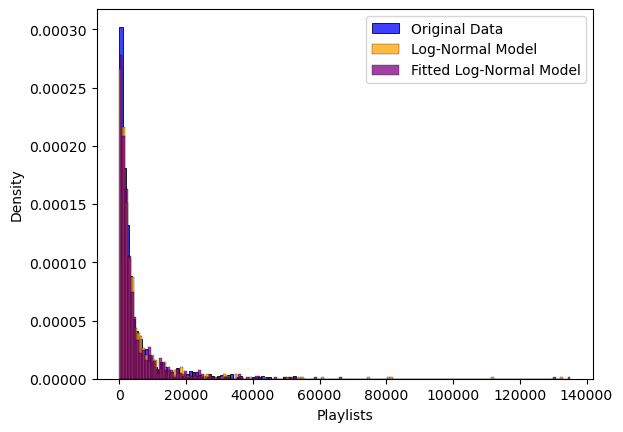

In [156]:
sns.histplot(playlists, color="blue", stat="density", label="Original Data")
sns.histplot(playLogNormSample, color="orange", stat="density", label="Log-Normal Model")
sns.histplot(playFitSample, color="purple", stat="density", label="Fitted Log-Normal Model")
thinkplot.config(xlabel="Playlists", ylabel="Density", legend=True)


### Calculations

We'll try using the ppf calculation, which is the inverse of the CDF, to find out how many playlists we need to be in to be in the 80th percentile of playlists. This calculation takes in a percentile rank, and returns the value of the variable that corresponds to that percentile.

In [157]:
#If we want to be in the 80% percentile of playlists, how many playlists do we need to be in?
cutoffPercentile = 0.8
cutoffPer = playFitFrozen.ppf(cutoffPercentile)
print(f"To be in the {cutoffPercentile*100}% percentile of playlists, you need to be in at least {cutoffPer:.0f} playlists.")

To be in the 80.0% percentile of playlists, you need to be in at least 6893 playlists.


## Beta Distribution - Energy

If we look at the energy value in the dataset, it is kind of a backwards version of lognormal data. We can model this with the beta distribution. 

<Axes: xlabel='energy_%', ylabel='Density'>

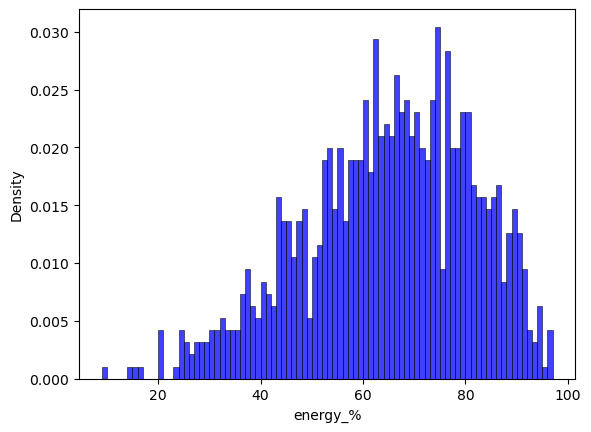

In [158]:
energy = dfSpotify["energy_%"]
sns.histplot(data=energy, color="blue", stat="density", binwidth=1)

#### Match and Model

This shape looks like it may match a beta distribution. Let's try to fit a beta distribution and see. The beta distribution is a continuous probability distribution defined on the interval [0, 1], and it is often used to model random variables that represent proportions or probabilities. Scipy allows the distribution to be shifted and scaled, so we can use it on our data. The beta distribution has two shape parameters, alpha and beta, which determine the shape of the distribution. 

<b>Note:</b> the beta distribution can take on a wide variety of shapes depending on the values of the shape parameters. 

Fitted Beta Parameters for energy_%: (5.530478496369, 2.6584025265831386, -8.045494984599145, 107.08976733973753)


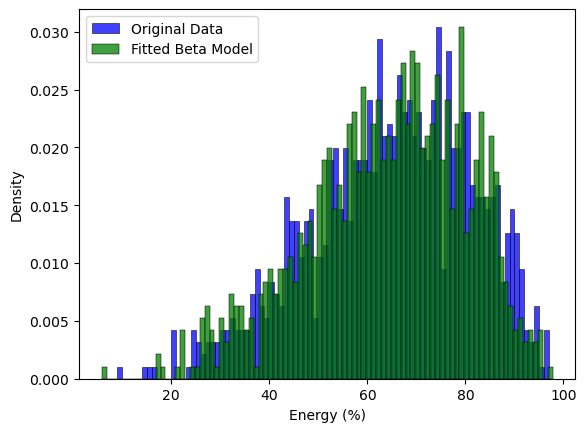

In [159]:
energyBeta = scipy.stats.beta.fit(energy, method="mm")
print("Fitted Beta Parameters for energy_%:", energyBeta)

energyBetaFrozen = scipy.stats.beta(*energyBeta)
energyBetaSample = energyBetaFrozen.rvs(size=len(energy))
sns.histplot(energy, color="blue", stat="density", binwidth=1, label="Original Data")
sns.histplot(energyBetaSample, color="green", stat="density", binwidth=1, label="Fitted Beta Model")
thinkplot.config(xlabel="Energy (%)", ylabel="Density", legend=True)

## Example - ER Dataset

This dataset contains several variables that we can potentially model with distributions. 

In [160]:
dfHospitals = pd.read_csv("data/unified_ER_dataset.csv")
dfHospitals.head()

,timestamp,hour_of_day,day_of_week,is_weekend,month,season,arrival_rate_base,is_surge,arrival_rate,available_doctors,...,patients_waiting,severity_level,occupancy_percent,waiting_time_minutes,crowding_level,patients_per_bed,staff_total,patients_per_staff,time_period,flow_pattern_type
0,2024-01-01 00:00:00,0,0,0,1,Winter,14,0,14,3,...,7,1,43,25,Moderate,1.000000,5,1.166667,Night,Busy Period
1,2024-01-01 01:00:00,1,0,0,1,Winter,11,0,11,1,...,8,2,34,34,Moderate,0.571429,4,1.600000,Night,Busy Period
2,2024-01-01 02:00:00,2,0,0,1,Winter,15,0,15,1,...,13,5,86,56,Critical,2.166667,5,2.166667,Night,Peak Demand
3,2024-01-01 03:00:00,3,0,0,1,Winter,12,0,12,2,...,9,1,37,19,Moderate,0.600000,6,1.285714,Night,Busy Period
4,2024-01-01 04:00:00,4,0,0,1,Winter,14,0,14,2,...,11,5,61,40,High,1.222222,6,1.571429,Night,Peak Demand


### Wait Times

We'll start with the wait times. We are going to the hospital, and we want to know how long we will have to wait. 

Ideally, we want to build a function like the one below, that predicts the length of our wait. We can do this in a nieve way, <b>based on the wait data, if we randomly show up, how long should we expect to wait?</b> Maybe it'll be fun!

In [161]:
def howLongDoIwait(numberOfVisits, model):
    '''
    This function takes in the number of visits and a model (frozen distribution) and returns the expected wait time for that number of visits.

    Parameters:
    numberOfVisits (int): The number of visits to the hospital to predict wait times for.
    model (frozen distribution): A frozen distribution object from scipy.stats representing the wait time distribution.
    '''
    pass

#### Explore Wait Times

We can plot the wait times to see what it looks like and what distribution it might be.

<Axes: xlabel='waiting_time_minutes', ylabel='Density'>

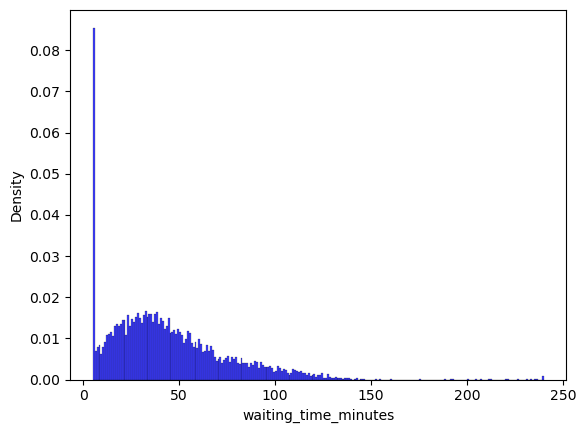

In [162]:
waits = dfHospitals["waiting_time_minutes"]
sns.histplot(data=waits, color="blue", stat="density", binwidth=1)

##### Odd Pattern in Wait Times

We can notice something odd in the data here. It appears that a large percentage of patients waited 5 minutes. This could be due to a number of reasons, but I would wager that this is just a default value assigned for people with virtually no wait time. So anyone who more-or-less walked in gets 5 minutes assigned no matter what. This obviously isn't something that fits directly into a distribution, so if we want to accurately predict our wait times, we need to handle it. 

In [163]:
waits5 = waits[waits <= 5]
waitsRest = waits[waits > 5]
percent5 = len(waits5) / len(waits) * 100
percentRest = len(waitsRest) / len(waits) * 100
print(f"Percentage of patients waiting <= 5 minutes: {percent5:.2f}%")
print(f"Percentage of patients waiting > 5 minutes: {percentRest:.2f}%")

Percentage of patients waiting <= 5 minutes: 8.55%
Percentage of patients waiting > 5 minutes: 91.45%


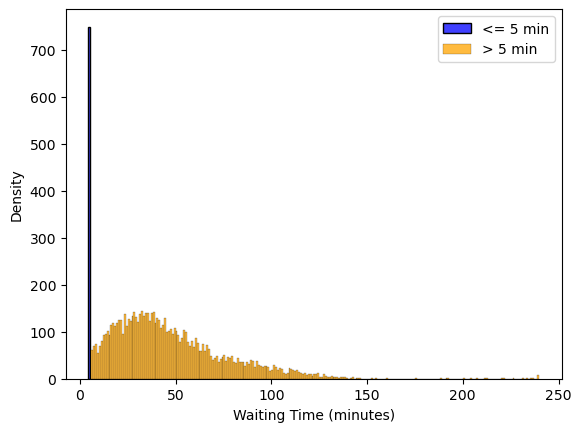

In [164]:
sns.histplot(data=waits5, color="blue", label="<= 5 min")
sns.histplot(data=waitsRest, color="orange", binwidth=1, label="> 5 min")
thinkplot.config(xlabel="Waiting Time (minutes)", ylabel="Density", legend=True)

#### Check the Distributed Data

We can take the part of the data that *does* follow a distribution and fit a model to it. For this one, I'm going to try a gamma distribution, which is a continuous distribution that is often used to model waiting times.

Fitted Gamma Parameters for patients waiting > 5 minutes: (2.082890104035247, 3.9318370936722267, 20.644611273384925)


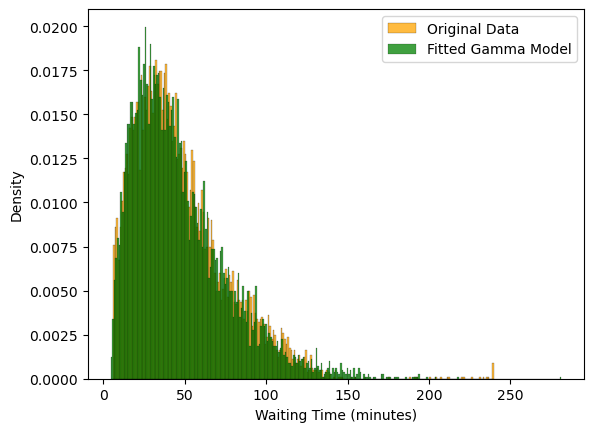

In [165]:
waitRestGamma = scipy.stats.gamma.fit(waitsRest)
print("Fitted Gamma Parameters for patients waiting > 5 minutes:", waitRestGamma)

waitRestGammaFrozen = scipy.stats.gamma(*waitRestGamma)
waitRestGammaSample = waitRestGammaFrozen.rvs(size=len(waitsRest))

sns.histplot(waitsRest, color="orange", stat="density", binwidth=1, label="Original Data")
sns.histplot(waitRestGammaSample, color="green", stat="density", binwidth=1, label="Fitted Gamma Model")
thinkplot.config(xlabel="Waiting Time (minutes)", ylabel="Density", legend=True)

#### Full (Naive) Model

We can now make a model and complete the function. We are doing this in a simple way, not predicting wait times conditional on time of day or hospital crowdedness, which would be what we want for truly accurate predictions. We will basically assume that we will wait some amount of time, randomly selected based on the real world distribution of wait times.

My strategy:
<ul>
<li> There is a ~8.5% chance that I won't wait, or bareley at all. </li>
<li> If I am not in that 8.5%, then I'll wait some amount of time, randomly selected from the gamma distribution that we fit to the data. </li>
</ul>

<Axes: ylabel='Density'>

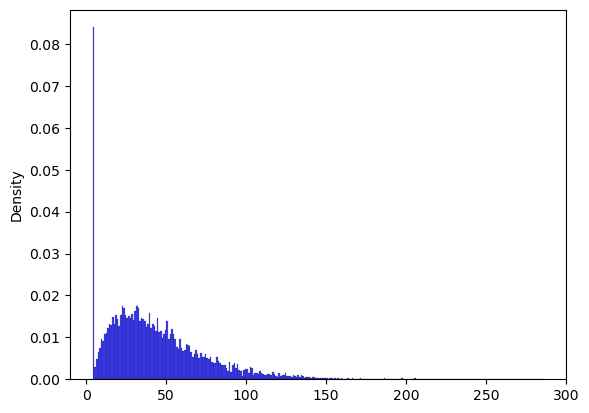

In [166]:
def howLongDoIwait(trials, modelFrozen):
    per5 = .0855
    perWait = 1 - per5

    results = []
    for _ in range(trials):
        if np.random.rand() < per5:
            results.append(5)
        else:
            waitTime = modelFrozen.rvs()
            results.append(waitTime)
    return results

vists100 = howLongDoIwait(10000, waitRestGammaFrozen)
sns.histplot(vists100, color="blue", stat="density", binwidth=1, label="Simulated Visits")

#### Results

It looks like the model is a pretty good fit to the data, our sample generated from the model looks very similar to the real data.

## Exercise - Patients Waiting

Try to do a similar thing for the number of patients waiting. 

<Axes: xlabel='patients_waiting', ylabel='Count'>

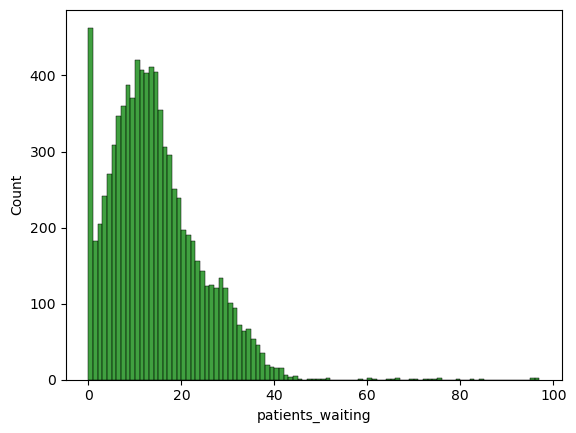

In [167]:
patients = dfHospitals["patients_waiting"]
sns.histplot(data=patients, color="green", binwidth=1)

## Exercises

For some more practice, we can try to model almost any of the other variables in any of these datasets. If you want to get an overview of the distributions in the data, you can use sns.pairplot() and look at the distributions of the variables down the spine of the output. The different distributions can be spotted by eyeball, then we can zoom in and do more checking. The distributions available in scipy are listed here: https://docs.scipy.org/doc/scipy/reference/stats.html 